# Real and synthetic transport and rearranged contours

Compare Gaussian-ball contours pushed through a pretrained conditional Neural OT or RealNVP model and its amortized rearrangement. Real datasets use the learned model density in the reference panel; synthetic datasets use their exact target density. Select `DATASET_NAME`, `MODEL_FAMILY`, and `MODEL_SEED` in the configuration cell below.

In [123]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.lines import Line2D
from matplotlib.ticker import LinearLocator
from scipy.ndimage import gaussian_filter
from scipy.stats import chi2

REPOSITORY_ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "src").is_dir()
)
sys.path.insert(0, str(REPOSITORY_ROOT / "src"))

from configs.calibrators import NormCalibratorConfig
from configs.conformal import TransportBasedConformalPredictorConfig
from configs.predictors.transport import (
    NeuralOptimalTransportPredictorConfig,
    NormalizingFlowPredictorConfig,
)
from conformal import TransportBasedConformalPredictor
from data.datasets.real import (
    BioDataset,
    BlogDataset,
    QM9Dataset,
    SCM20dDataset,
    SGEMMDataset,
)
from data.datasets.synthetic import (
    BananaDataset,
    SinusoidalTransportDataset,
    StarShapedGaussianDataset,
)
from data.loaders import make_xy_dataloader
from experimentation import load_experiment_config
from predictors.rearranged_transport import AmortizedRearrangedTransport
from predictors.transport import (
    NeuralOptimalTransportPredictor,
    NormalizingFlowPredictor,
)

# Choose the dataset, transport family, and matching pretrained model seed here.
DATASET_NAME = "bio"
# Real: blog, bio, qm9, scm20d, sgemm
# Synthetic: banana, star_shaped_gaussian, sinusoidal_transport
MODEL_FAMILY = "neural_ot"  # one of: "neural_ot", "realnvp"
MODEL_SEED = 1 # one of: 0, 1, 2, 3, 4
DEVICE = "cpu"

DATASET_OPTIONS = {
    "blog": {
        "class": BlogDataset,
        "label": "Blog",
        "axis_labels": (
            "Time passed since publication",
            "Amount of comments received",
        ),
        "plot_dimensions": (0, 1),
        "result_subdirectory": ("blog", "sweep_neural_ot_run"),
    },
    "bio": {
        "class": BioDataset,
        "label": "Bio",
        "axis_labels": ("F7", "F9"),
        "result_subdirectory": ("bio", "sweep_neural_ot_run"),
        "plot_dimensions": (0, 1),
    },
    "qm9": {
        "class": QM9Dataset,
        "label": "QM9 HOMO/LUMO",
        "axis_labels": ("HOMO (eV)", "LUMO (eV)"),
        "plot_dimensions": (2, 3),
        "result_subdirectory": ("qm9", "sweep_neural_ot_run"),
    },
    "sgemm": {
        "class": SGEMMDataset,
        "label": "SGEMM coordinates 1/2",
        "axis_labels": ("log Run1 (ms)", "log Run2 (ms)"),
        "plot_dimensions": (0, 1),
    },
    "scm20d": {
        "class": SCM20dDataset,
        "label": "SCM20D coordinates 1/2",
        "axis_labels": ("LBL", "MTLp2A"),
        "plot_dimensions": (0, 1),
        "result_subdirectory": ("scm20d", "sweep_neural_ot_run"),
    },
    "banana": {
        "class": BananaDataset,
        "label": "Banana",
        "axis_labels": ("Y1", "Y2"),
        "plot_dimensions": (0, 1),
        "result_subdirectory": ("synthetic", "banana"),
        "supported_model_families": ("neural_ot",),
        "exact_density": True,
    },
    "star_shaped_gaussian": {
        "class": StarShapedGaussianDataset,
        "label": "Star-shaped Gaussian",
        "axis_labels": ("Y1", "Y2"),
        "plot_dimensions": (0, 1),
        "result_subdirectory": ("synthetic", "star_shaped_gaussian"),
        "supported_model_families": ("neural_ot",),
        "exact_density": True,
    },
    "sinusoidal_transport": {
        "class": SinusoidalTransportDataset,
        "label": "Sinusoidal transport",
        "axis_labels": ("Y1", "Y2"),
        "plot_dimensions": (0, 1),
        "result_subdirectory": ("synthetic", "sinusoidal_transport"),
        "supported_model_families": ("neural_ot",),
        "exact_density": True,
    },
}
if DATASET_NAME not in DATASET_OPTIONS:
    raise ValueError(
        f"Unknown DATASET_NAME {DATASET_NAME!r}; choose one of "
        f"{tuple(DATASET_OPTIONS)}."
    )
MODEL_OPTIONS = {
    "neural_ot": {
        "label": "Neural OT",
        "run_name": "transport_neural_ot_l2_huge",
        "rearranged_run_name": "transport_neural_ot_rearranged_l2_huge",
        "config_class": NeuralOptimalTransportPredictorConfig,
        "predictor_class": NeuralOptimalTransportPredictor,
    },
    "realnvp": {
        "label": "RealNVP",
        "run_name": "transport_realnvp_l2",
        "rearranged_run_name": "transport_realnvp_rearranged_l2",
        "config_class": NormalizingFlowPredictorConfig,
        "predictor_class": NormalizingFlowPredictor,
    },
}
if MODEL_FAMILY not in MODEL_OPTIONS:
    raise ValueError("MODEL_FAMILY must be 'neural_ot' or 'realnvp'.")
if MODEL_SEED not in range(5):
    raise ValueError("MODEL_SEED must be an integer from 0 to 4.")

dataset_option = DATASET_OPTIONS[DATASET_NAME]
model_option = MODEL_OPTIONS[MODEL_FAMILY]
supported_model_families = dataset_option.get(
    "supported_model_families", tuple(MODEL_OPTIONS)
)
if MODEL_FAMILY not in supported_model_families:
    raise ValueError(
        f"{DATASET_NAME!r} has saved checkpoints only for model families "
        f"{supported_model_families}, not {MODEL_FAMILY!r}."
    )
DATASET_LABEL = dataset_option["label"]
MODEL_LABEL = model_option["label"]
X_LABEL, Y_LABEL = dataset_option["axis_labels"]
PLOT_DIMENSIONS = dataset_option["plot_dimensions"]
seed_directory = f"seed_{MODEL_SEED:02d}"
result_subdirectory = dataset_option.get(
    "result_subdirectory", (DATASET_NAME, "base_run")
)
result_root = (
    REPOSITORY_ROOT / "benchmark/downloads/results"
).joinpath(*result_subdirectory)
base_run_directory = result_root / model_option["run_name"] / seed_directory
rearranged_run_directory = (
    result_root / model_option["rearranged_run_name"] / seed_directory
)
CHECKPOINT_PATH = base_run_directory / "base/predictor.pt"
REARRANGEMENT_PATH = rearranged_run_directory / "rearrangement/predictor.pt"
EXPERIMENT_CONFIG_PATH = rearranged_run_directory / "config.json"
for path in (CHECKPOINT_PATH, REARRANGEMENT_PATH, EXPERIMENT_CONFIG_PATH):
    if not path.is_file():
        raise FileNotFoundError(f"Required benchmark artifact not found: {path}")

PLOT_SEED = 7
N_COVARIATES = 6
BOUNDARY_POINTS = 400
DENSITY_GRID_SIZE = 240
DENSITY_SAMPLES = 200_000
SELECTED_TEST_INDEX = 4070  # Wrapped modulo the test-set size if needed.

plt.rcParams.update({"figure.dpi": 120, "font.size": 15})

In [124]:
experiment_config = load_experiment_config(EXPERIMENT_CONFIG_PATH)
if experiment_config.dataset_config.type != DATASET_NAME:
    raise ValueError("The selected experiment and dataset do not match.")

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model_config = model_option["config_class"].model_validate(
    {**checkpoint["config"], "device": DEVICE}
)
predictor = model_option["predictor_class"](model_config)
predictor.load_state_dict(checkpoint["state_dict"])
predictor.eval()
if max(PLOT_DIMENSIONS) >= predictor.y_dim:
    raise ValueError("Selected plot dimensions exceed the model output dimension.")
rearranged_predictor = AmortizedRearrangedTransport.load(
    REARRANGEMENT_PATH, map_location=DEVICE
)
rearranged_predictor.eval()

dataset_config = experiment_config.dataset_config.model_copy(
    update={"device": DEVICE}
)
dataset = dataset_option["class"](dataset_config)
splits = dataset.get_splits()
test_data = splits.test

print(
    f"Loaded {DATASET_LABEL} {MODEL_LABEL}, seed {MODEL_SEED}, on {DEVICE}."
)
print(f"{MODEL_LABEL}: {CHECKPOINT_PATH.relative_to(REPOSITORY_ROOT)}")
print(f"Rearrangement: {REARRANGEMENT_PATH.relative_to(REPOSITORY_ROOT)}")

Loaded Bio Neural OT, seed 1, on cpu.
Neural OT: benchmark/downloads/results/bio/sweep_neural_ot_run/transport_neural_ot_l2_huge/seed_01/base/predictor.pt
Rearrangement: benchmark/downloads/results/bio/sweep_neural_ot_run/transport_neural_ot_rearranged_l2_huge/seed_01/rearrangement/predictor.pt


In [125]:
def gaussian_ball_boundary(mass, n_points=BOUNDARY_POINTS):
    """Central 2D slice of the model's full-dimensional Gaussian ball."""
    radius = np.sqrt(chi2.ppf(mass, df=predictor.y_dim))
    angles = torch.linspace(0, 2 * torch.pi, n_points + 1)
    boundary = torch.zeros(n_points + 1, predictor.y_dim)
    boundary[:, PLOT_DIMENSIONS[0]] = radius * torch.cos(angles)
    boundary[:, PLOT_DIMENSIONS[1]] = radius * torch.sin(angles)
    return boundary


def pushforward_contour(model, x, mass):
    u = gaussian_ball_boundary(mass)
    x_batch = x.unsqueeze(0).expand(u.shape[0], -1)
    if isinstance(model, AmortizedRearrangedTransport):
        y = model.pushforward(x=x_batch, u=u, coverage_mass=mass)
    else:
        y = model.pushforward(x=x_batch, u=u)
    return y[:, list(PLOT_DIMENSIONS)].cpu().numpy()


def padded_bounds(contours, padding=0.12):
    points = np.concatenate(contours, axis=0)
    lower = points.min(axis=0)
    upper = points.max(axis=0)
    margin = padding * (upper - lower)
    return lower - margin, upper + margin


def density_grid(x, grid_size=DENSITY_GRID_SIZE):
    use_exact_density = dataset_option.get("exact_density", False)
    if use_exact_density:
        with torch.no_grad():
            mapped_points = dataset.sample_conditional(
                x=x.unsqueeze(0), n_samples=DENSITY_SAMPLES
            ).squeeze(0)
    else:
        generator = torch.Generator().manual_seed(PLOT_SEED)
        latent_points = torch.randn(
            DENSITY_SAMPLES, predictor.y_dim, generator=generator
        )
        mapped_batches = []
        for u_batch in latent_points.split(8192):
            x_batch = x.unsqueeze(0).expand(u_batch.shape[0], -1)
            y_batch = predictor.pushforward(x=x_batch, u=u_batch)
            mapped_batches.append(y_batch.cpu())
        mapped_points = torch.cat(mapped_batches)

    mapped_points = (
        mapped_points[:, list(PLOT_DIMENSIONS)].cpu().numpy()
    )
    lower = np.quantile(mapped_points, 0.0005, axis=0)
    upper = np.quantile(mapped_points, 0.9995, axis=0)
    margin = 0.05 * (upper - lower)
    lower -= margin
    upper += margin
    response_1_edges = np.linspace(lower[0], upper[0], grid_size + 1)
    response_2_edges = np.linspace(lower[1], upper[1], grid_size + 1)
    response_1 = 0.5 * (response_1_edges[:-1] + response_1_edges[1:])
    response_2 = 0.5 * (response_2_edges[:-1] + response_2_edges[1:])
    response_1_grid, response_2_grid = np.meshgrid(response_1, response_2)

    if use_exact_density:
        grid_points = torch.as_tensor(
            np.column_stack((
                response_1_grid.ravel(), response_2_grid.ravel()
            )),
            device=x.device,
            dtype=x.dtype,
        )
        x_batch = x.unsqueeze(0).expand(grid_points.shape[0], -1)
        with torch.no_grad():
            density = dataset.log_prob(
                x=x_batch, y=grid_points
            ).exp().reshape(grid_size, grid_size).cpu().numpy()
    else:
        density, _, _ = np.histogram2d(
            mapped_points[:, 1],
            mapped_points[:, 0],
            bins=(response_2_edges, response_1_edges),
            density=True,
        )
        density = gaussian_filter(density, sigma=2.0)

    return response_1_grid, response_2_grid, density


def hdr_thresholds(density, response_1_grid, response_2_grid, masses):
    cell_area = (
        (response_1_grid[0, 1] - response_1_grid[0, 0])
        * (response_2_grid[1, 0] - response_2_grid[0, 0])
    )
    sorted_density = np.sort(density.ravel())[::-1]
    cumulative_mass = np.cumsum(sorted_density) * cell_area

    if cumulative_mass[-1] < max(masses):
        raise ValueError("The density grid is too small to estimate the requested HDR.")

    return {
        mass: sorted_density[np.searchsorted(cumulative_mass, mass)]
        for mass in masses
    }

## Select representative test covariates

In [126]:
rng = np.random.default_rng(PLOT_SEED)
test_indices = rng.choice(
    len(test_data.x), size=N_COVARIATES, replace=False
)

## Conditional density, HDRs, and transport pushforwards

For real datasets, the reference density is estimated from 200,000 fixed-seed Gaussian samples pushed through the selected base transport and a lightly smoothed 2D histogram. For synthetic datasets, the plotting bounds come from 200,000 ground-truth samples and the exact dataset density is evaluated on the grid. The HDR threshold for mass $\alpha$ is found by sorting density-grid cells from highest to lowest density and accumulating $p(y\mid x)\,dy$ until the mass reaches $\alpha$. The solid curves are learned transport pushforwards and the dotted curves are reference HDRs.

For multidimensional real targets, the density and HDR panel is the selected two-coordinate marginal of the full model: HOMO/LUMO from four targets for QM9, the first two runtime coordinates from four targets for SGEMM, and LBL/MTLp2A from 16 targets for SCM20D. The two transport panels show the corresponding projection of the transported central two-dimensional slice of each full-dimensional Gaussian probability ball; all other latent coordinates are fixed to zero.

5404


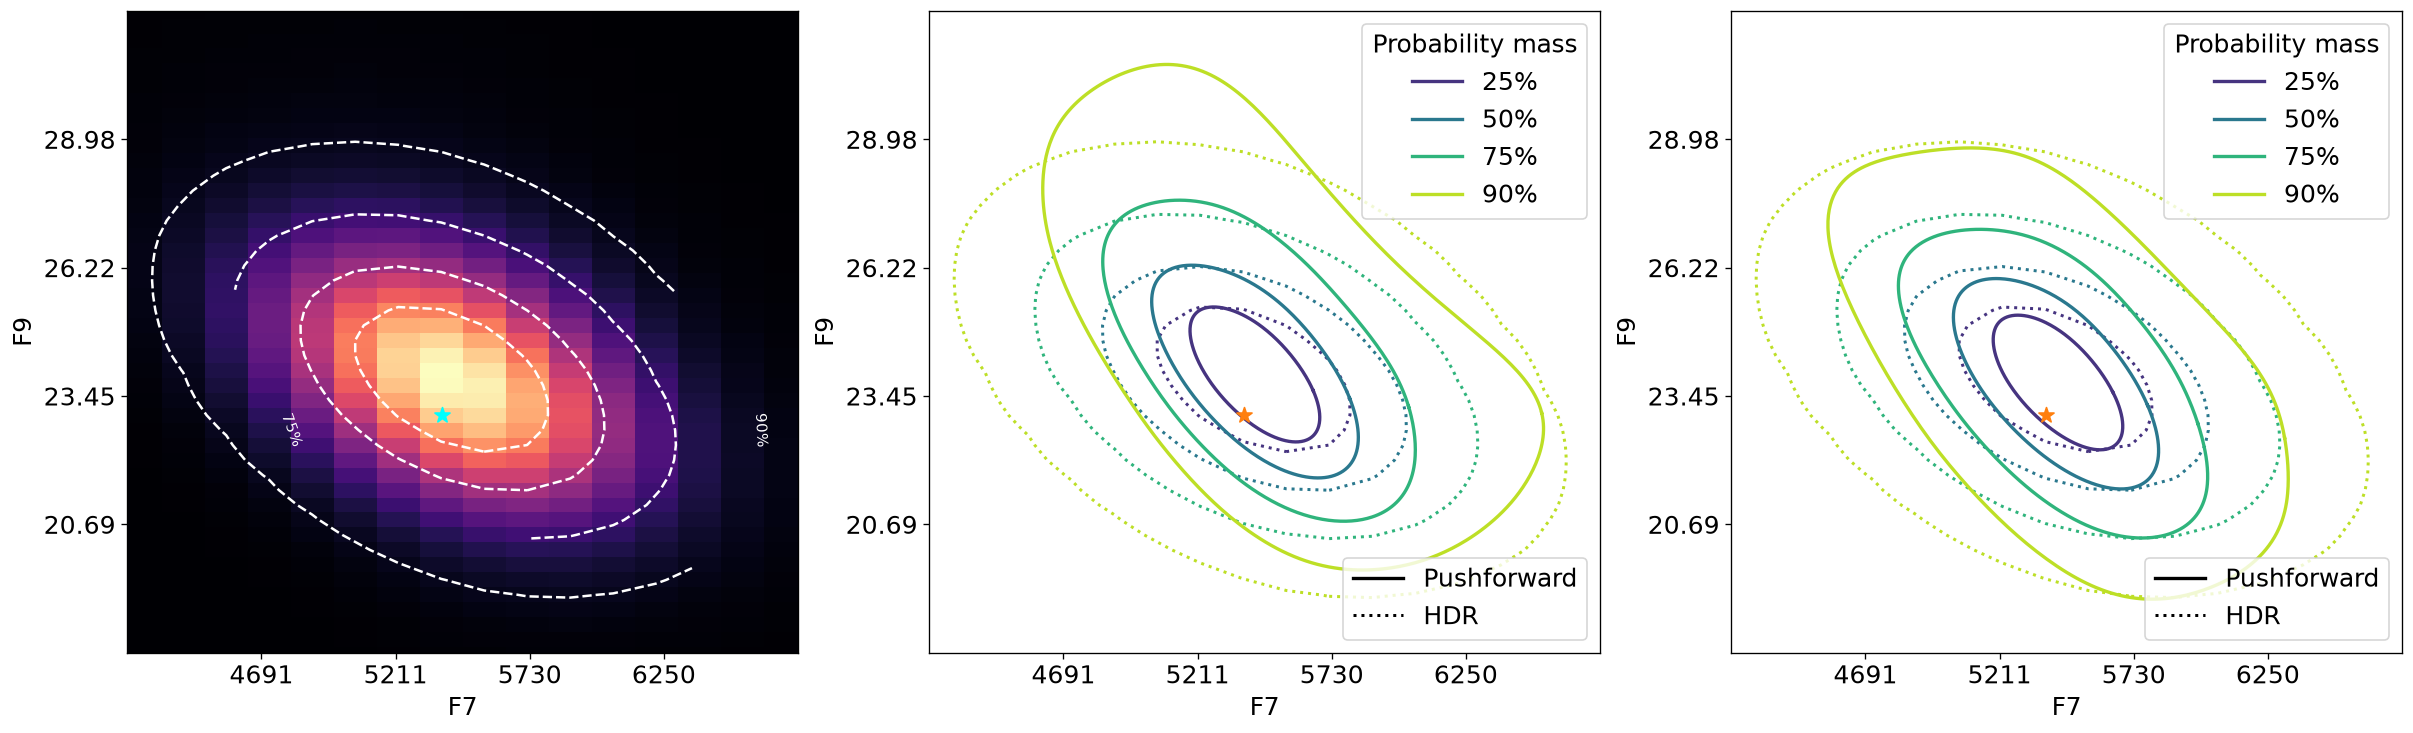

In [140]:
masses = (0.25, 0.50, 0.75, 0.90)
selected_index = 9067 % len(test_data.x)
selected_index = torch.randint(0, len(test_data.x), (1,)).item()
selected_x = test_data.x[selected_index]
selected_y = (
    test_data.y[selected_index, list(PLOT_DIMENSIONS)].cpu().numpy()
)
contours = {
    mass: pushforward_contour(predictor, selected_x, mass)
    for mass in masses
}
rearranged_contours = {
    mass: pushforward_contour(rearranged_predictor, selected_x, mass)
    for mass in masses
}
response_1_grid, response_2_grid, density = density_grid(selected_x)
thresholds = hdr_thresholds(
    density, response_1_grid, response_2_grid, masses
)

hdr_90_mask = density >= thresholds[0.90]
hdr_90_points = np.column_stack((
    response_1_grid[hdr_90_mask], response_2_grid[hdr_90_mask]
))
lower, upper = padded_bounds(
    [*contours.values(), *rearranged_contours.values(), hdr_90_points],
    padding=0.10,
)
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(masses)))

fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)

heatmap = axes[0].pcolormesh(
    response_1_grid,
    response_2_grid,
    density,
    shading="auto",
    cmap="magma",
    edgecolors="none",
    linewidth=0,
    antialiased=False,
    rasterized=True,
)
for mass in masses:
    hdr = axes[0].contour(
        response_1_grid,
        response_2_grid,
        density,
        levels=[thresholds[mass]],
        colors="white",
        linestyles="--",
        linewidths=1.5,
    )
    axes[0].clabel(
        hdr, fmt={thresholds[mass]: f"{mass:.0%}"}, fontsize=9
    )
axes[0].scatter(*selected_y, color="cyan", marker="*", s=90, zorder=3)
axes[0].set_title("")

model_panels = (
    (axes[1], f"", contours),
    (axes[2], "", rearranged_contours),
)
for axis, title, model_contours in model_panels:
    for mass, color in zip(masses, colors):
        contour = model_contours[mass]
        axis.plot(
            contour[:, 0],
            contour[:, 1],
            color=color,
            linewidth=2,
            label=f"{mass:.0%}",
        )
        axis.contour(
            response_1_grid,
            response_2_grid,
            density,
            levels=[thresholds[mass]],
            colors=[color],
            linestyles=":",
            linewidths=1.8,
        )
    axis.scatter(
        *selected_y, color="tab:orange", marker="*", s=90, zorder=3
    )
    axis.set_title(title)
    mass_legend = axis.legend(title="Probability mass", loc="upper right")
    axis.add_artist(mass_legend)
    axis.legend(
        handles=[
            Line2D([0], [0], color="black", linewidth=2, label="Pushforward"),
            Line2D(
                [0],
                [0],
                color="black",
                linewidth=1.8,
                linestyle=":",
                label="HDR",
            ),
        ],
        loc="lower right",
    )

for axis in axes.flat:
    axis.set_xlabel(X_LABEL)
    axis.set_ylabel(Y_LABEL)
    axis.set_xlim(lower[0], upper[0])
    axis.set_ylim(lower[1], upper[1])
    axis.xaxis.set_major_locator(LinearLocator(6))
    axis.yaxis.set_major_locator(LinearLocator(6))
    for axis_ticks in (axis.xaxis.get_major_ticks(), axis.yaxis.get_major_ticks()):
        for edge_tick in (axis_ticks[0], axis_ticks[-1]):
            edge_tick.tick1line.set_visible(False)
            edge_tick.tick2line.set_visible(False)
            edge_tick.label1.set_visible(False)
            edge_tick.label2.set_visible(False)
            edge_tick.gridline.set_visible(False)

# fig.suptitle(
#     f"{DATASET_LABEL}, {MODEL_LABEL}, seed {MODEL_SEED}: density and transport contours",
#     fontsize=16,
# )

# fig.savefig(
#     REPOSITORY_ROOT / f"figures/{DATASET_NAME}_{MODEL_FAMILY}_rearrangement_seed_{MODEL_SEED:02d}.pdf",
#     bbox_inches="tight",
# )
print(selected_index)
plt.show()

## Conformalized 90% prediction regions

Both predictors are calibrated on the full calibration split at 90% coverage (10% significance) using the L2 norm of their pullback scores.

In [6]:
COVERAGE_MASS = 0.90
CALIBRATION_BATCH_SIZE = 512
VOLUME_MC_SAMPLES = 2_000
VOLUME_BATCH_SIZE = 1_024
VOLUME_SEED = 7

calibration_loader = make_xy_dataloader(
    dataset.get_splits().calibration,
    batch_size=CALIBRATION_BATCH_SIZE,
    shuffle=False,
)

conformal_config = TransportBasedConformalPredictorConfig(
    coverage_mass=COVERAGE_MASS,
    calibrator=NormCalibratorConfig(p=2.0),
    volume_mc_samples=VOLUME_MC_SAMPLES,
    volume_batch_size=VOLUME_BATCH_SIZE,
    volume_seed=VOLUME_SEED,
)

base_conformal = TransportBasedConformalPredictor(
    predictor=predictor, config=conformal_config
).calibrate(calibration_loader)
rearranged_conformal = TransportBasedConformalPredictor(
    predictor=rearranged_predictor, config=conformal_config
).calibrate(calibration_loader)

In [ ]:
volume_x = torch.cat((selected_x.unsqueeze(0), test_data.x[test_indices]), dim=0)
models = (
    (MODEL_LABEL, base_conformal),
    ("Rearranged transport", rearranged_conformal),
)

results = []
for name, conformal_predictor in models:
    log_volumes = conformal_predictor.estimate_log_volume(volume_x).cpu()
    results.append((
        name,
        float(conformal_predictor.threshold.cpu()),
        float(log_volumes[0]),
        float(log_volumes[1:].mean()),
        float(log_volumes[1:].std(unbiased=False)),
    ))

print("90% conformal regions (Monte Carlo log-volume in target space)")
print(f"{'Model':<24} {'Radius':>9} {'Selected x':>13} {'Mean of six':>13} {'Std of six':>12}")
for name, radius, selected_volume, mean_volume, std_volume in results:
    print(
        f"{name:<24} {radius:9.4f} {selected_volume:13.4f} "
        f"{mean_volume:13.4f} {std_volume:12.4f}"
    )